<a href="https://colab.research.google.com/github/Revanth-reddy080/PyTorch-DeepLearning/blob/main/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [55]:
# Check for GPU
!nvidia-smi

Sun Jul 19 04:12:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [56]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

1.add more layers and units

2.try modifying optimizers ans loss function

3.use the less regularized version

4.Train for Longer


## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [57]:
import requests
from pathlib import Path
import zipfile

data_path = Path("data/")
image_path = data_path/"pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory exists.")
else :
  print(f"{image_path} doesnt exist ,creating ...")
  image_path.mkdir(parents=True,
                   exist_ok=True)
with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading data ...")
  f.write(request.content)

with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping data....")
  zip_ref.extractall(image_path)


data/pizza_steak_sushi directory exists.
Unzipping data....


In [58]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [59]:
walk_through_dir(data_path)

There are 1 directories and 1 images in 'data'.
There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.


In [60]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

pizza


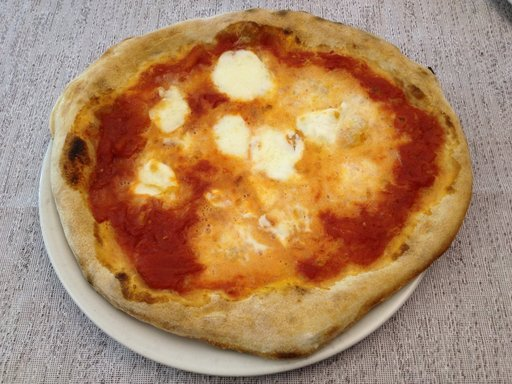

In [61]:
# Visualize an image
import random
from PIL import Image

random.seed(42)

image_path_list = list(image_path.glob("*/*/*"))

rand_img = random.choice(image_path_list)

rand_img_class = rand_img.parent.stem

img = Image.open(rand_img)

print(rand_img_class)

img

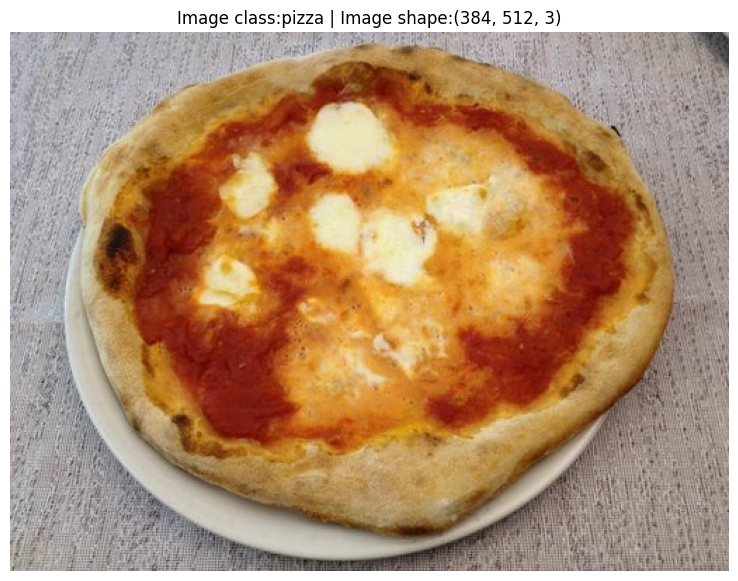

In [62]:
# Do the image visualization with matplotlib
import matplotlib.pyplot as plt
import numpy as np

img_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_array)
plt.title(f"Image class:{rand_img_class} | Image shape:{img_array.shape}")
plt.axis(False);


We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [76]:
# 3.1 Transforming data with torchvision.transforms
import torchvision
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(size=(128,128)),
    transforms.ToTensor()
])

In [77]:
# Write a function to plot transformed images
def plot_img(img,image_class):
  plt.figure(figsize=(6,8))
  plt.imshow(img.permute(1,2,0))
  plt.title(f"Image class:{image_class} | Image size:{img.shape}")
  plt.axis(False)

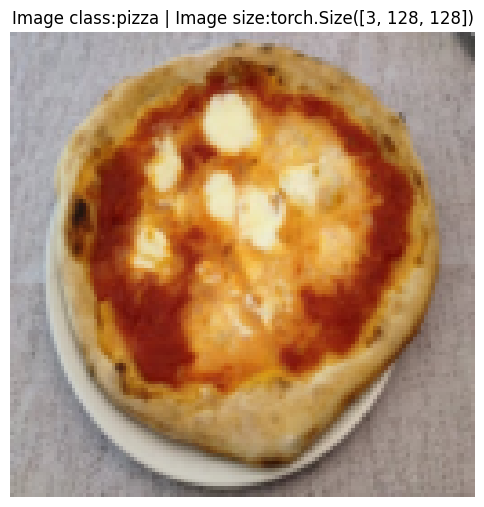

In [78]:
img_tensor_for_plotting = transform(Image.open(rand_img))

plot_img(img_tensor_for_plotting,rand_img_class)

### Load image data using `ImageFolder`

In [66]:
from torchvision import datasets
from torch.utils.data.dataloader import DataLoader

In [67]:
# Use ImageFolder to create dataset(s)
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=transform)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=transform)

train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [68]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [69]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [70]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [71]:
# Turn train and test Datasets into DataLoaders
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             shuffle=False)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7ea2be9d64b0>,
 <torch.utils.data.dataloader.DataLoader at 0x7ea2beb52900>)

In [72]:
# How many batches of images are in our data loaders?
len(train_dataloader),len(test_dataloader)

(8, 3)

## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [79]:
class TinyVGGModel(nn.Module):
  def __init__(self,input_size,hidden_units,output_size) :
     super().__init__()

     self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_size,
                   out_channels=hidden_units,
                   kernel_size=3,
                   padding=0,
                   stride=1),
         nn.ReLU(),
         nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   padding=0,
                   stride=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2)
      )

     self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   padding=0,
                   stride=1),
         nn.ReLU(),
         nn.Conv2d(in_channels=hidden_units,
                   out_channels=hidden_units,
                   kernel_size=3,
                   padding=0,
                   stride=1),
         nn.ReLU(),
         nn.MaxPool2d(kernel_size=2)
      )

     self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = 29*29*hidden_units,out_features=output_size)
    )

  def forward(self,x):
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [80]:
model_0 = TinyVGGModel(3,10,3).to(device)
model_0

TinyVGGModel(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8410, out_features=3, bias=True)
  )
)

In [81]:
!pip install torchinfo

In [82]:
from torchinfo import summary

summary(model_0,input_size=[1,3,128,128])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGModel                             [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 62, 62]           --
│    └─Conv2d: 2-1                       [1, 10, 126, 126]         280
│    └─ReLU: 2-2                         [1, 10, 126, 126]         --
│    └─Conv2d: 2-3                       [1, 10, 124, 124]         910
│    └─ReLU: 2-4                         [1, 10, 124, 124]         --
│    └─MaxPool2d: 2-5                    [1, 10, 62, 62]           --
├─Sequential: 1-2                        [1, 10, 29, 29]           --
│    └─Conv2d: 2-6                       [1, 10, 60, 60]           910
│    └─ReLU: 2-7                         [1, 10, 60, 60]           --
│    └─Conv2d: 2-8                       [1, 10, 58, 58]           910
│    └─ReLU: 2-9                         [1, 10, 58, 58]           --
│    └─MaxPool2d: 2-10                   [1, 10, 29, 29]           --
├─Sequentia

In [95]:
img_set,lablel_set = next(iter(train_dataloader))

In [97]:
class_names

['pizza', 'steak', 'sushi']

In [98]:
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [99]:
img = img_set[0]
label = lablel_set[0]
img.shape,label

(torch.Size([3, 128, 128]), tensor(1))

In [102]:
model_0(img.unsqueeze(0).to(device))

tensor([[-0.0118,  0.0054, -0.0030]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

## 4. Create training and testing functions for `model_0`.

In [103]:
from sklearn.metrics import accuracy_score

In [123]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

  # Put the model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader and data batches
  for batch,(X,y) in enumerate(dataloader):

    X,y = X.to(device),y.to(device)
    # Send data to target device

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate and accumulate loss
    loss = loss_fn(y_pred,y)
    train_loss += loss.item()

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Calculate and accumualte accuracy metric across all batches
    acc = accuracy_score(y.cpu(),torch.argmax(y_pred,dim=1).cpu())
    train_acc += acc

  # Adjust metrics to get average loss and average accuracy per batch
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  return train_loss, train_acc

In [124]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

  # Put model in eval mode
  model.eval()

  # Setup the test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Turn on inference context manager
  with torch.inference_mode():

    for batch,(X,y) in enumerate(dataloader):
    # Loop through DataLoader batches

      X,y = X.to(device),y.to(device)
      # Send data to target device

      test_pred = model(X)
      # 1. Forward pass
      loss = loss_fn(test_pred,y)
      test_loss += loss.item()
      # 2. Calculuate and accumulate loss
      test_acc += accuracy_score(y.cpu(),torch.argmax(test_pred,dim=1).cpu())
      # Calculate and accumulate accuracy

  test_loss /= len(dataloader)
  test_acc /= len(dataloader)
  # Adjust metrics to get average loss and accuracy per batch

  return test_loss, test_acc

In [125]:
from tqdm.auto import tqdm

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

  # Create results dictionary
  results = {"train_loss": [],
             "train_acc": [],
             "test_loss": [],
             "test_acc": []}

  # Loop through the training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs)):
    # Train step
    train_loss, train_acc = train_step(model=model,
                                       dataloader=train_dataloader,
                                       loss_fn=loss_fn,
                                       optimizer=optimizer)
    # Test step
    test_loss, test_acc = test_step(model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn)

    # Print out what's happening
    print(f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
    )

    # Update the results dictionary
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  # Return the results dictionary
  return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.

In [126]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0999 | train_acc: 0.3008 | test_loss: 1.0996 | test_acc: 0.2083
Epoch: 2 | train_loss: 1.0903 | train_acc: 0.5391 | test_loss: 1.1114 | test_acc: 0.2812
Epoch: 3 | train_loss: 1.0745 | train_acc: 0.4336 | test_loss: 1.1332 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.0846 | train_acc: 0.3125 | test_loss: 1.1330 | test_acc: 0.2604
Epoch: 5 | train_loss: 1.0599 | train_acc: 0.4844 | test_loss: 1.0893 | test_acc: 0.3835


{'train_loss': [1.0998929291963577,
  1.0902720391750336,
  1.0744788497686386,
  1.0846198946237564,
  1.0598982125520706],
 'train_acc': [0.30078125, 0.5390625, 0.43359375, 0.3125, 0.484375],
 'test_loss': [1.0996230045954387,
  1.111351490020752,
  1.133162836233775,
  1.1330039699872334,
  1.0892612934112549],
 'test_acc': [0.20833333333333334,
  0.28125,
  0.2604166666666667,
  0.2604166666666667,
  0.3835227272727273]}

In [128]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8835 | train_acc: 0.6289 | test_loss: 1.1873 | test_acc: 0.3324
Epoch: 2 | train_loss: 0.8752 | train_acc: 0.6367 | test_loss: 1.1873 | test_acc: 0.3011
Epoch: 3 | train_loss: 0.8189 | train_acc: 0.6484 | test_loss: 1.1229 | test_acc: 0.3835
Epoch: 4 | train_loss: 0.6984 | train_acc: 0.6953 | test_loss: 1.0688 | test_acc: 0.4233
Epoch: 5 | train_loss: 0.7013 | train_acc: 0.7148 | test_loss: 1.2413 | test_acc: 0.3532
Epoch: 6 | train_loss: 0.6420 | train_acc: 0.7109 | test_loss: 1.1463 | test_acc: 0.5246
Epoch: 7 | train_loss: 0.5790 | train_acc: 0.7539 | test_loss: 1.3605 | test_acc: 0.3428
Epoch: 8 | train_loss: 0.6314 | train_acc: 0.6250 | test_loss: 1.2250 | test_acc: 0.3220
Epoch: 9 | train_loss: 0.6576 | train_acc: 0.7578 | test_loss: 1.2548 | test_acc: 0.4015
Epoch: 10 | train_loss: 0.5814 | train_acc: 0.7656 | test_loss: 1.3257 | test_acc: 0.4148
Epoch: 11 | train_loss: 0.5699 | train_acc: 0.8086 | test_loss: 1.1238 | test_acc: 0.4138
Epoch: 12 | train_l

In [129]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_0 = TinyVGGModel(3,10,3)
model_0.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=50)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1479 | train_acc: 0.3008 | test_loss: 1.1321 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.1258 | train_acc: 0.2695 | test_loss: 1.0547 | test_acc: 0.5417
Epoch: 3 | train_loss: 1.1118 | train_acc: 0.3086 | test_loss: 1.1105 | test_acc: 0.2604
Epoch: 4 | train_loss: 1.1038 | train_acc: 0.3047 | test_loss: 1.0980 | test_acc: 0.2708
Epoch: 5 | train_loss: 1.1129 | train_acc: 0.2695 | test_loss: 1.1212 | test_acc: 0.1979
Epoch: 6 | train_loss: 1.0823 | train_acc: 0.4648 | test_loss: 1.0834 | test_acc: 0.5133
Epoch: 7 | train_loss: 1.0804 | train_acc: 0.3789 | test_loss: 1.0888 | test_acc: 0.2595
Epoch: 8 | train_loss: 1.0589 | train_acc: 0.5078 | test_loss: 1.0614 | test_acc: 0.5947
Epoch: 9 | train_loss: 1.0621 | train_acc: 0.4141 | test_loss: 1.0250 | test_acc: 0.5947
Epoch: 10 | train_loss: 0.9527 | train_acc: 0.5469 | test_loss: 1.0406 | test_acc: 0.4934
Epoch: 11 | train_loss: 0.9126 | train_acc: 0.6172 | test_loss: 1.0306 | test_acc: 0.4451
Epoch: 12 | train_l

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [130]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGGModel(3,20,3)
model_1.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)

model_0_results = train(model=model_1,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0737 | train_acc: 0.4062 | test_loss: 1.1307 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.1191 | train_acc: 0.3242 | test_loss: 1.0822 | test_acc: 0.4025
Epoch: 3 | train_loss: 1.0064 | train_acc: 0.5742 | test_loss: 1.0882 | test_acc: 0.3229
Epoch: 4 | train_loss: 1.0184 | train_acc: 0.4023 | test_loss: 1.0627 | test_acc: 0.3314
Epoch: 5 | train_loss: 0.9591 | train_acc: 0.4766 | test_loss: 1.0530 | test_acc: 0.3419
Epoch: 6 | train_loss: 0.9591 | train_acc: 0.5156 | test_loss: 1.0040 | test_acc: 0.3835
Epoch: 7 | train_loss: 0.8529 | train_acc: 0.6250 | test_loss: 0.9235 | test_acc: 0.5227
Epoch: 8 | train_loss: 0.8252 | train_acc: 0.6484 | test_loss: 0.9699 | test_acc: 0.4545
Epoch: 9 | train_loss: 0.9851 | train_acc: 0.5312 | test_loss: 1.0592 | test_acc: 0.4138
Epoch: 10 | train_loss: 0.7391 | train_acc: 0.6953 | test_loss: 0.9454 | test_acc: 0.4943
Epoch: 11 | train_loss: 0.7646 | train_acc: 0.6172 | test_loss: 0.9627 | test_acc: 0.5947
Epoch: 12 | train_l

It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [131]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [132]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.


Excellent, we now have double the training and testing images...

In [133]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [136]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
  transforms.Resize((128, 128)),
  transforms.ToTensor()
])

# Create datasets
train_data_20 = datasets.ImageFolder(root=train_data_20_percent_path,
                                  transform=simple_transform)

test_data_20 = datasets.ImageFolder(root=test_data_20_percent_path,
                                 transform = simple_transform)

# Create dataloaders
train_dataloader_20 = DataLoader(dataset=train_data_20,
                                 batch_size=32,
                                 shuffle=True)
test_dataloader_20 = DataLoader(dataset=test_data_20,
                                batch_size=32,
                                shuffle=False)


In [137]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_2 = TinyVGGModel(3,20,3).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_2.parameters(),
                             lr=0.001)

model_0_results = train(model=model_2,
                        train_dataloader=train_dataloader_20,
                        test_dataloader=test_dataloader_20,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=20)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1035 | train_acc: 0.3875 | test_loss: 1.0998 | test_acc: 0.3500
Epoch: 2 | train_loss: 1.0937 | train_acc: 0.3125 | test_loss: 1.0892 | test_acc: 0.3909
Epoch: 3 | train_loss: 1.0433 | train_acc: 0.4437 | test_loss: 0.9867 | test_acc: 0.4898
Epoch: 4 | train_loss: 0.9079 | train_acc: 0.5188 | test_loss: 0.9657 | test_acc: 0.5517
Epoch: 5 | train_loss: 0.9342 | train_acc: 0.5833 | test_loss: 0.9066 | test_acc: 0.5506
Epoch: 6 | train_loss: 0.8809 | train_acc: 0.5896 | test_loss: 0.9193 | test_acc: 0.5364
Epoch: 7 | train_loss: 0.8546 | train_acc: 0.6188 | test_loss: 0.9317 | test_acc: 0.5898
Epoch: 8 | train_loss: 0.7880 | train_acc: 0.6833 | test_loss: 0.8552 | test_acc: 0.6131
Epoch: 9 | train_loss: 0.9295 | train_acc: 0.5958 | test_loss: 0.8795 | test_acc: 0.5977
Epoch: 10 | train_loss: 0.7994 | train_acc: 0.6813 | test_loss: 0.8785 | test_acc: 0.5886
Epoch: 11 | train_loss: 0.7058 | train_acc: 0.7292 | test_loss: 0.9619 | test_acc: 0.5858
Epoch: 12 | train_l

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

In [139]:
with open("pizza_dad.jpeg","wb") as f:
  request = requests.get("https://raw.github.com/mrdbourke/pytorch-deep-learning/main/data/04-pizza-dad.jpeg")
  f.write(request.content)

In [160]:
img = Image.open("pizza_dad.jpeg")

In [161]:
img = simple_transform(img)
img = img.unsqueeze(dim=0)
img.shape

torch.Size([1, 3, 128, 128])

In [162]:
torch.argmax(model_2(img.to(device)),dim=1)

tensor([0], device='cuda:0')

In [163]:
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}